In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Bank_Marketing_Campaign.csv')
df

,id,customer_age,job_type,marital,education,default,balance,housing_loan,personal_loan,communication_type,day_of_month,month,last_contact_duration,num_contacts_in_campaign,days_since_prev_campaign_contact,num_contacts_prev_campaign,prev_campaign_outcome,term_deposit_subscribed
0,id_43823,28.0,management,single,tertiary,no,285.0,yes,no,unknown,26,jun,303.0,4.0,NaN,0,unknown,0
1,id_32289,34.0,blue-collar,married,secondary,no,934.0,no,yes,cellular,18,nov,143.0,2.0,132.0,1,other,0
2,id_10523,46.0,technician,married,secondary,no,656.0,no,no,cellular,5,feb,101.0,4.0,NaN,0,unknown,0
3,id_43951,34.0,services,single,secondary,no,2.0,yes,no,unknown,20,may,127.0,3.0,NaN,0,unknown,0
4,id_40992,41.0,blue-collar,married,primary,no,1352.0,yes,no,cellular,13,may,49.0,2.0,NaN,0,unknown,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31642,id_27290,58.0,admin.,married,secondary,no,567.0,yes,no,cellular,2,feb,99.0,2.0,265.0,3,other,0
31643,id_20428,51.0,management,married,tertiary,no,1072.0,no,no,unknown,20,jun,31.0,7.0,NaN,0,unknown,0
31644,id_44679,41.0,unemployed,married,primary,no,242.0,yes,no,unknown,23,may,89.0,2.0,NaN,0,unknown,0
31645,id_4841,48.0,services,married,secondary,no,2699.0,no,no,cellular,11,aug,216.0,6.0,NaN,0,unknown,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31647 entries, 0 to 31646
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                31647 non-null  object 
 1   customer_age                      31028 non-null  float64
 2   job_type                          31647 non-null  object 
 3   marital                           31497 non-null  object 
 4   education                         31647 non-null  object 
 5   default                           31647 non-null  object 
 6   balance                           31248 non-null  float64
 7   housing_loan                      31647 non-null  object 
 8   personal_loan                     31498 non-null  object 
 9   communication_type                31647 non-null  object 
 10  day_of_month                      31647 non-null  int64  
 11  month                             31647 non-null  object 
 12  last

In [4]:
null_v = (df.isnull().sum() / df.shape[0])*100
null_v.sort_values(ascending = False)

days_since_prev_campaign_contact    81.622271
customer_age                         1.955952
balance                              1.260783
last_contact_duration                0.982716
marital                              0.473979
personal_loan                        0.470819
num_contacts_in_campaign             0.353904
id                                   0.000000
default                              0.000000
job_type                             0.000000
communication_type                   0.000000
housing_loan                         0.000000
education                            0.000000
month                                0.000000
day_of_month                         0.000000
num_contacts_prev_campaign           0.000000
prev_campaign_outcome                0.000000
term_deposit_subscribed              0.000000
dtype: float64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
#cat_col = df.select_dtypes(include = 'object').columns.difference([id]).tolist()
#cat_col

cat_col = [df.columns[i] for i in range(1,df.shape[1]-1) if df.iloc[: , i].dtype=='O']
cat_col

['job_type',
 'marital',
 'education',
 'default',
 'housing_loan',
 'personal_loan',
 'communication_type',
 'month',
 'prev_campaign_outcome']

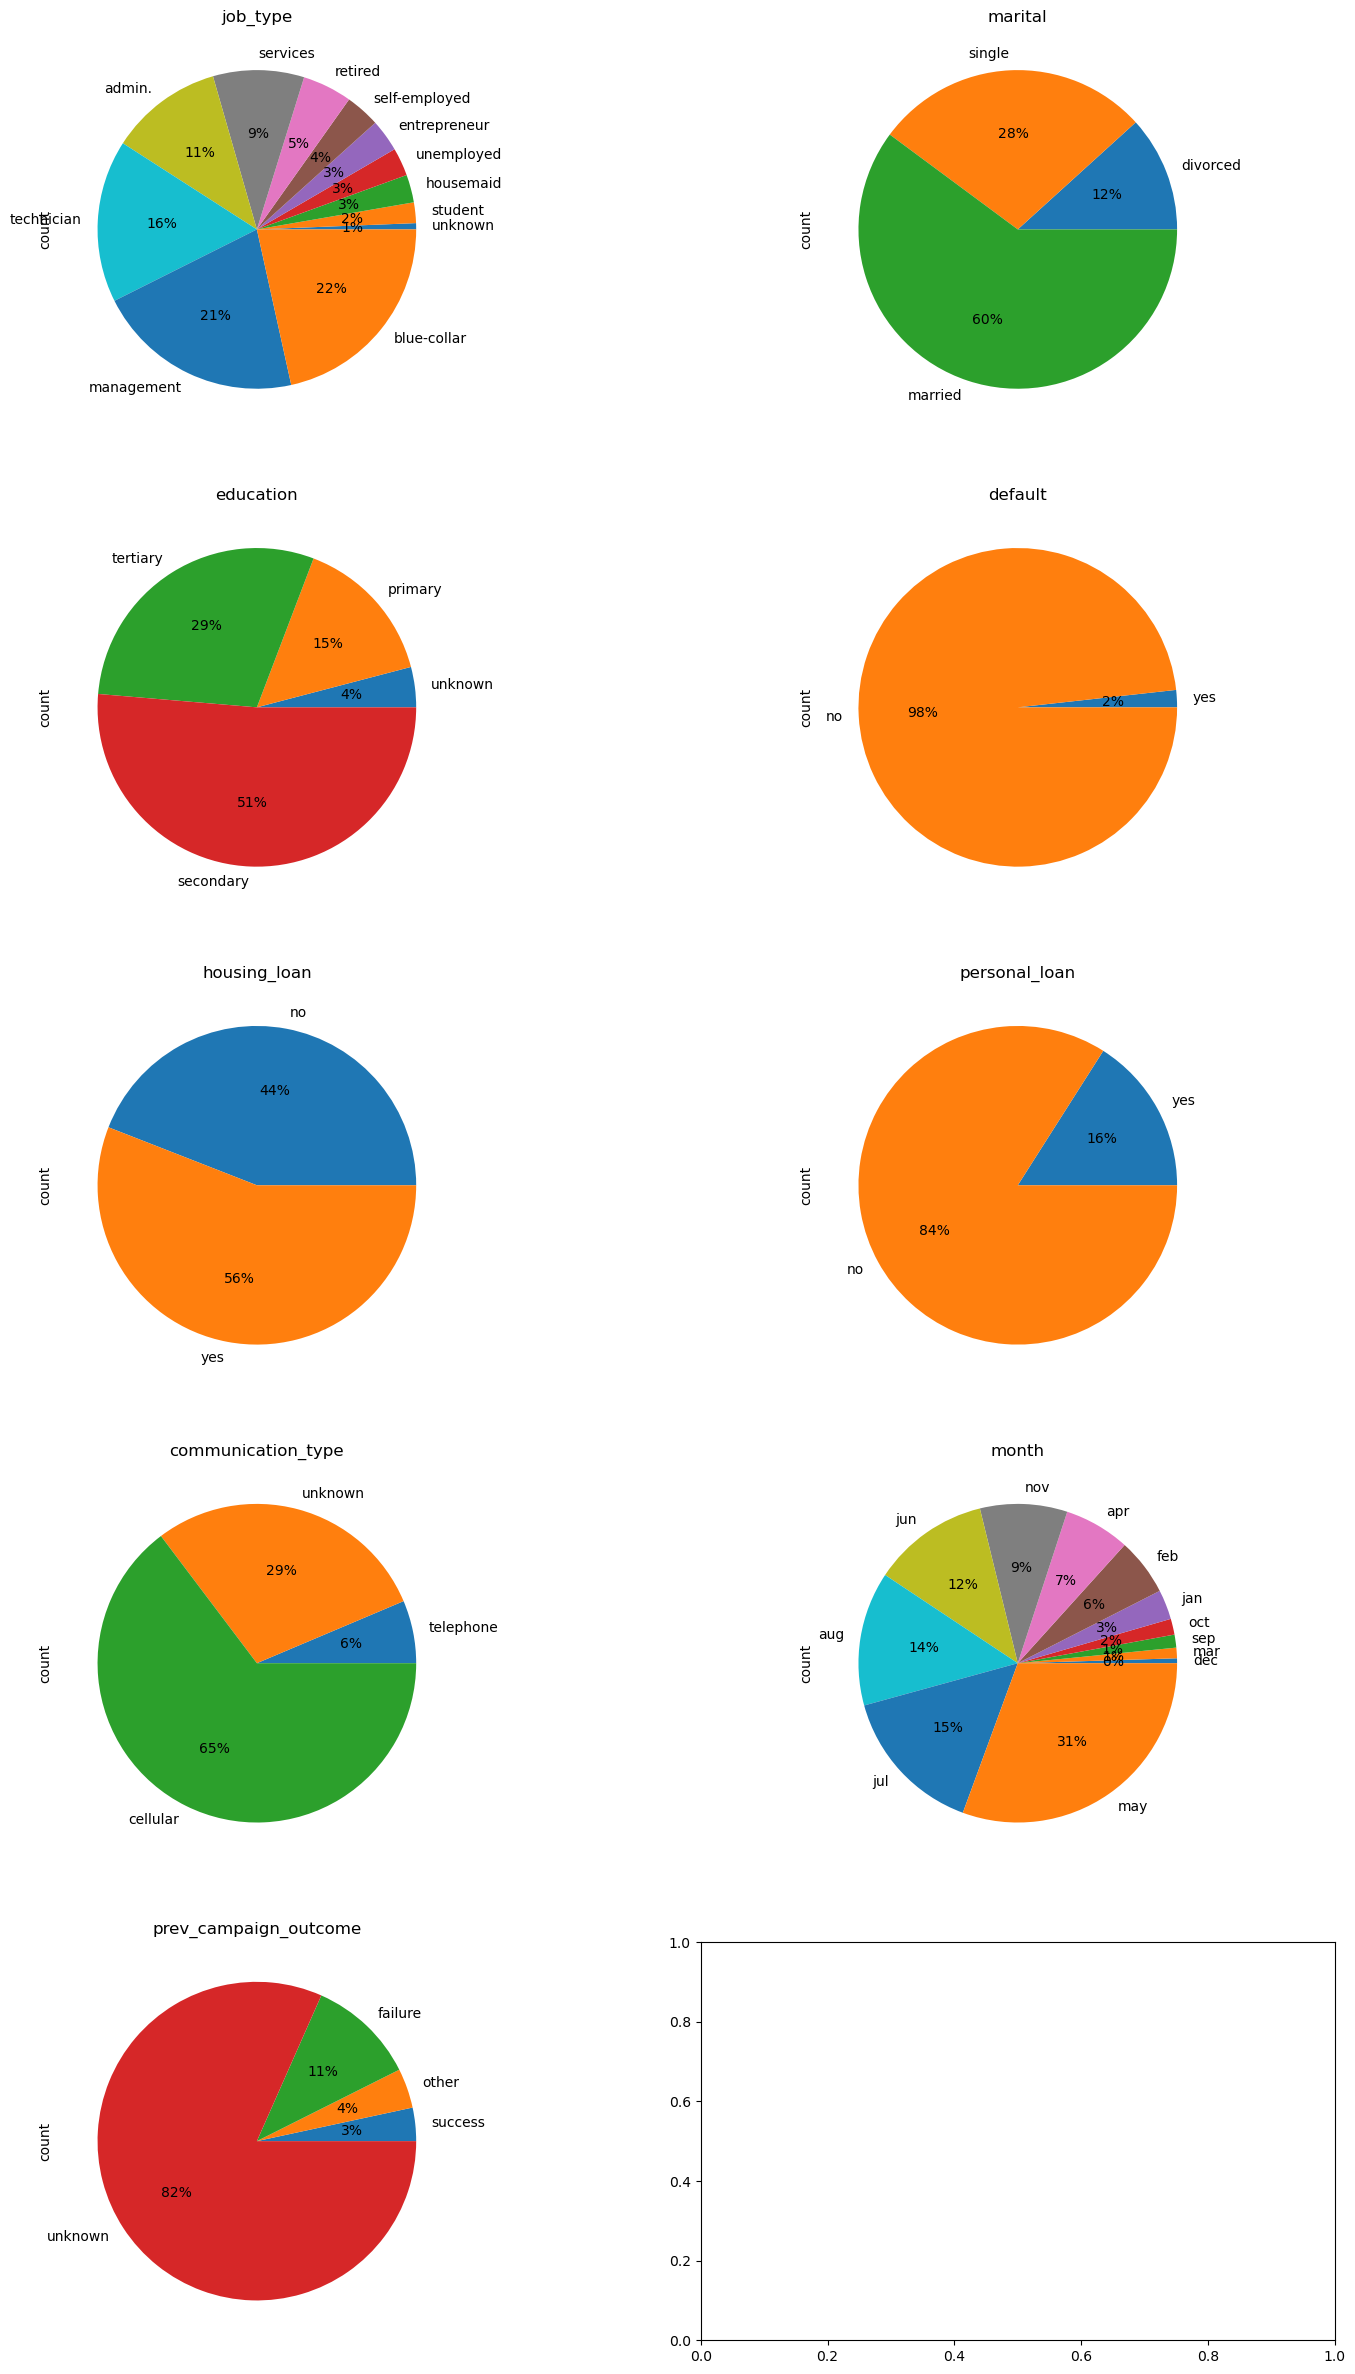

In [7]:
fig, axes = plt.subplots(5, 2, figsize=(18, 30))
axes = axes.flatten()

for ax, column in zip(axes, cat_col):
    df[column].value_counts(ascending = True).plot(
        kind='pie',
        ax=ax,
        title=column,
        autopct='%.0f%%'
    )


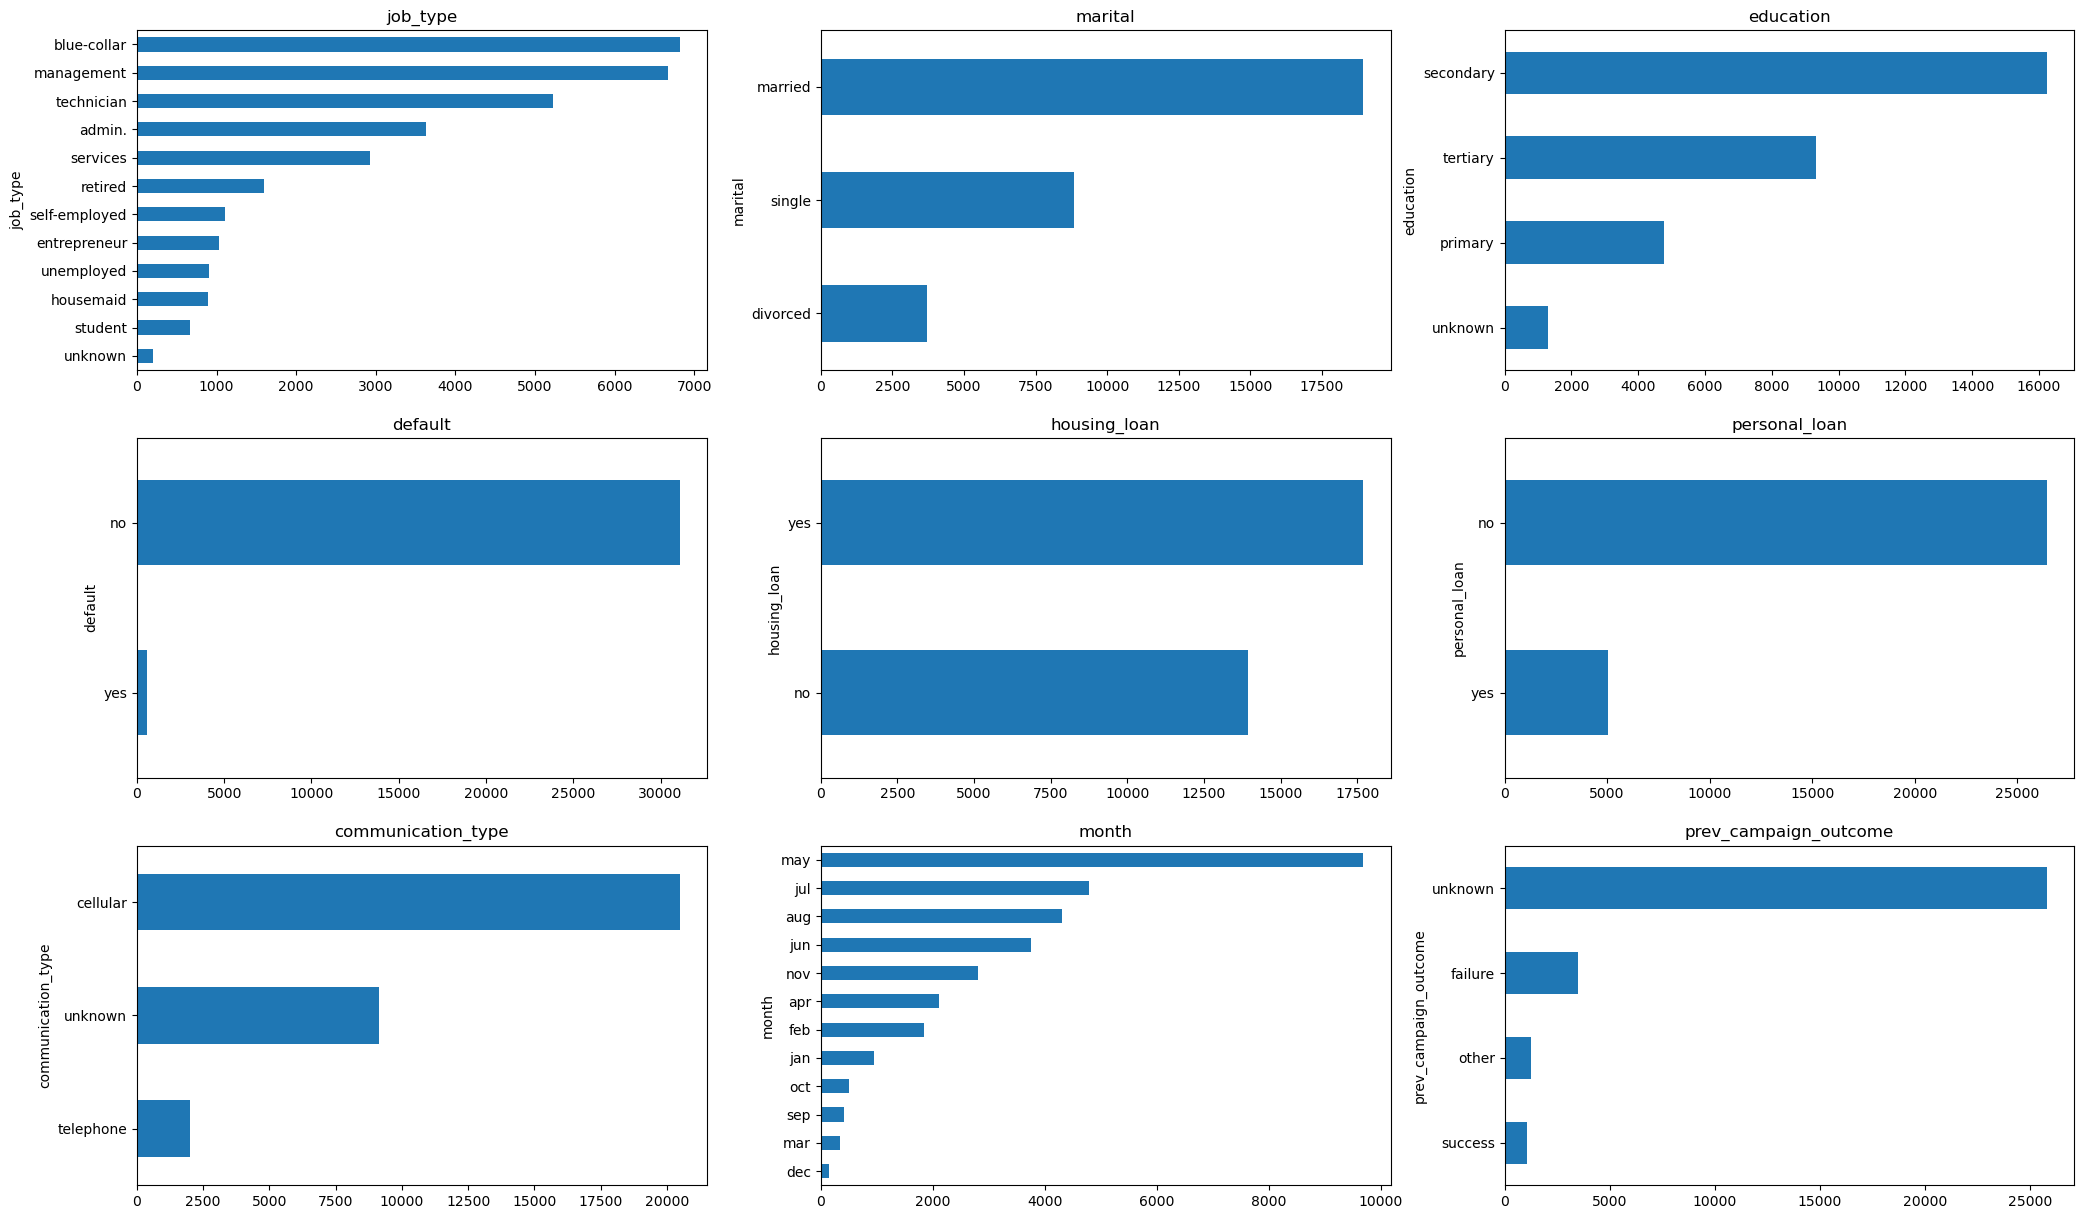

In [8]:
fig ,axes = plt.subplots(3,3 , figsize=(25,15))
axes = axes.flatten()
for col , ax in zip(cat_col , axes):
    df[col].value_counts(ascending = True).plot.barh(ax = ax , title = col)


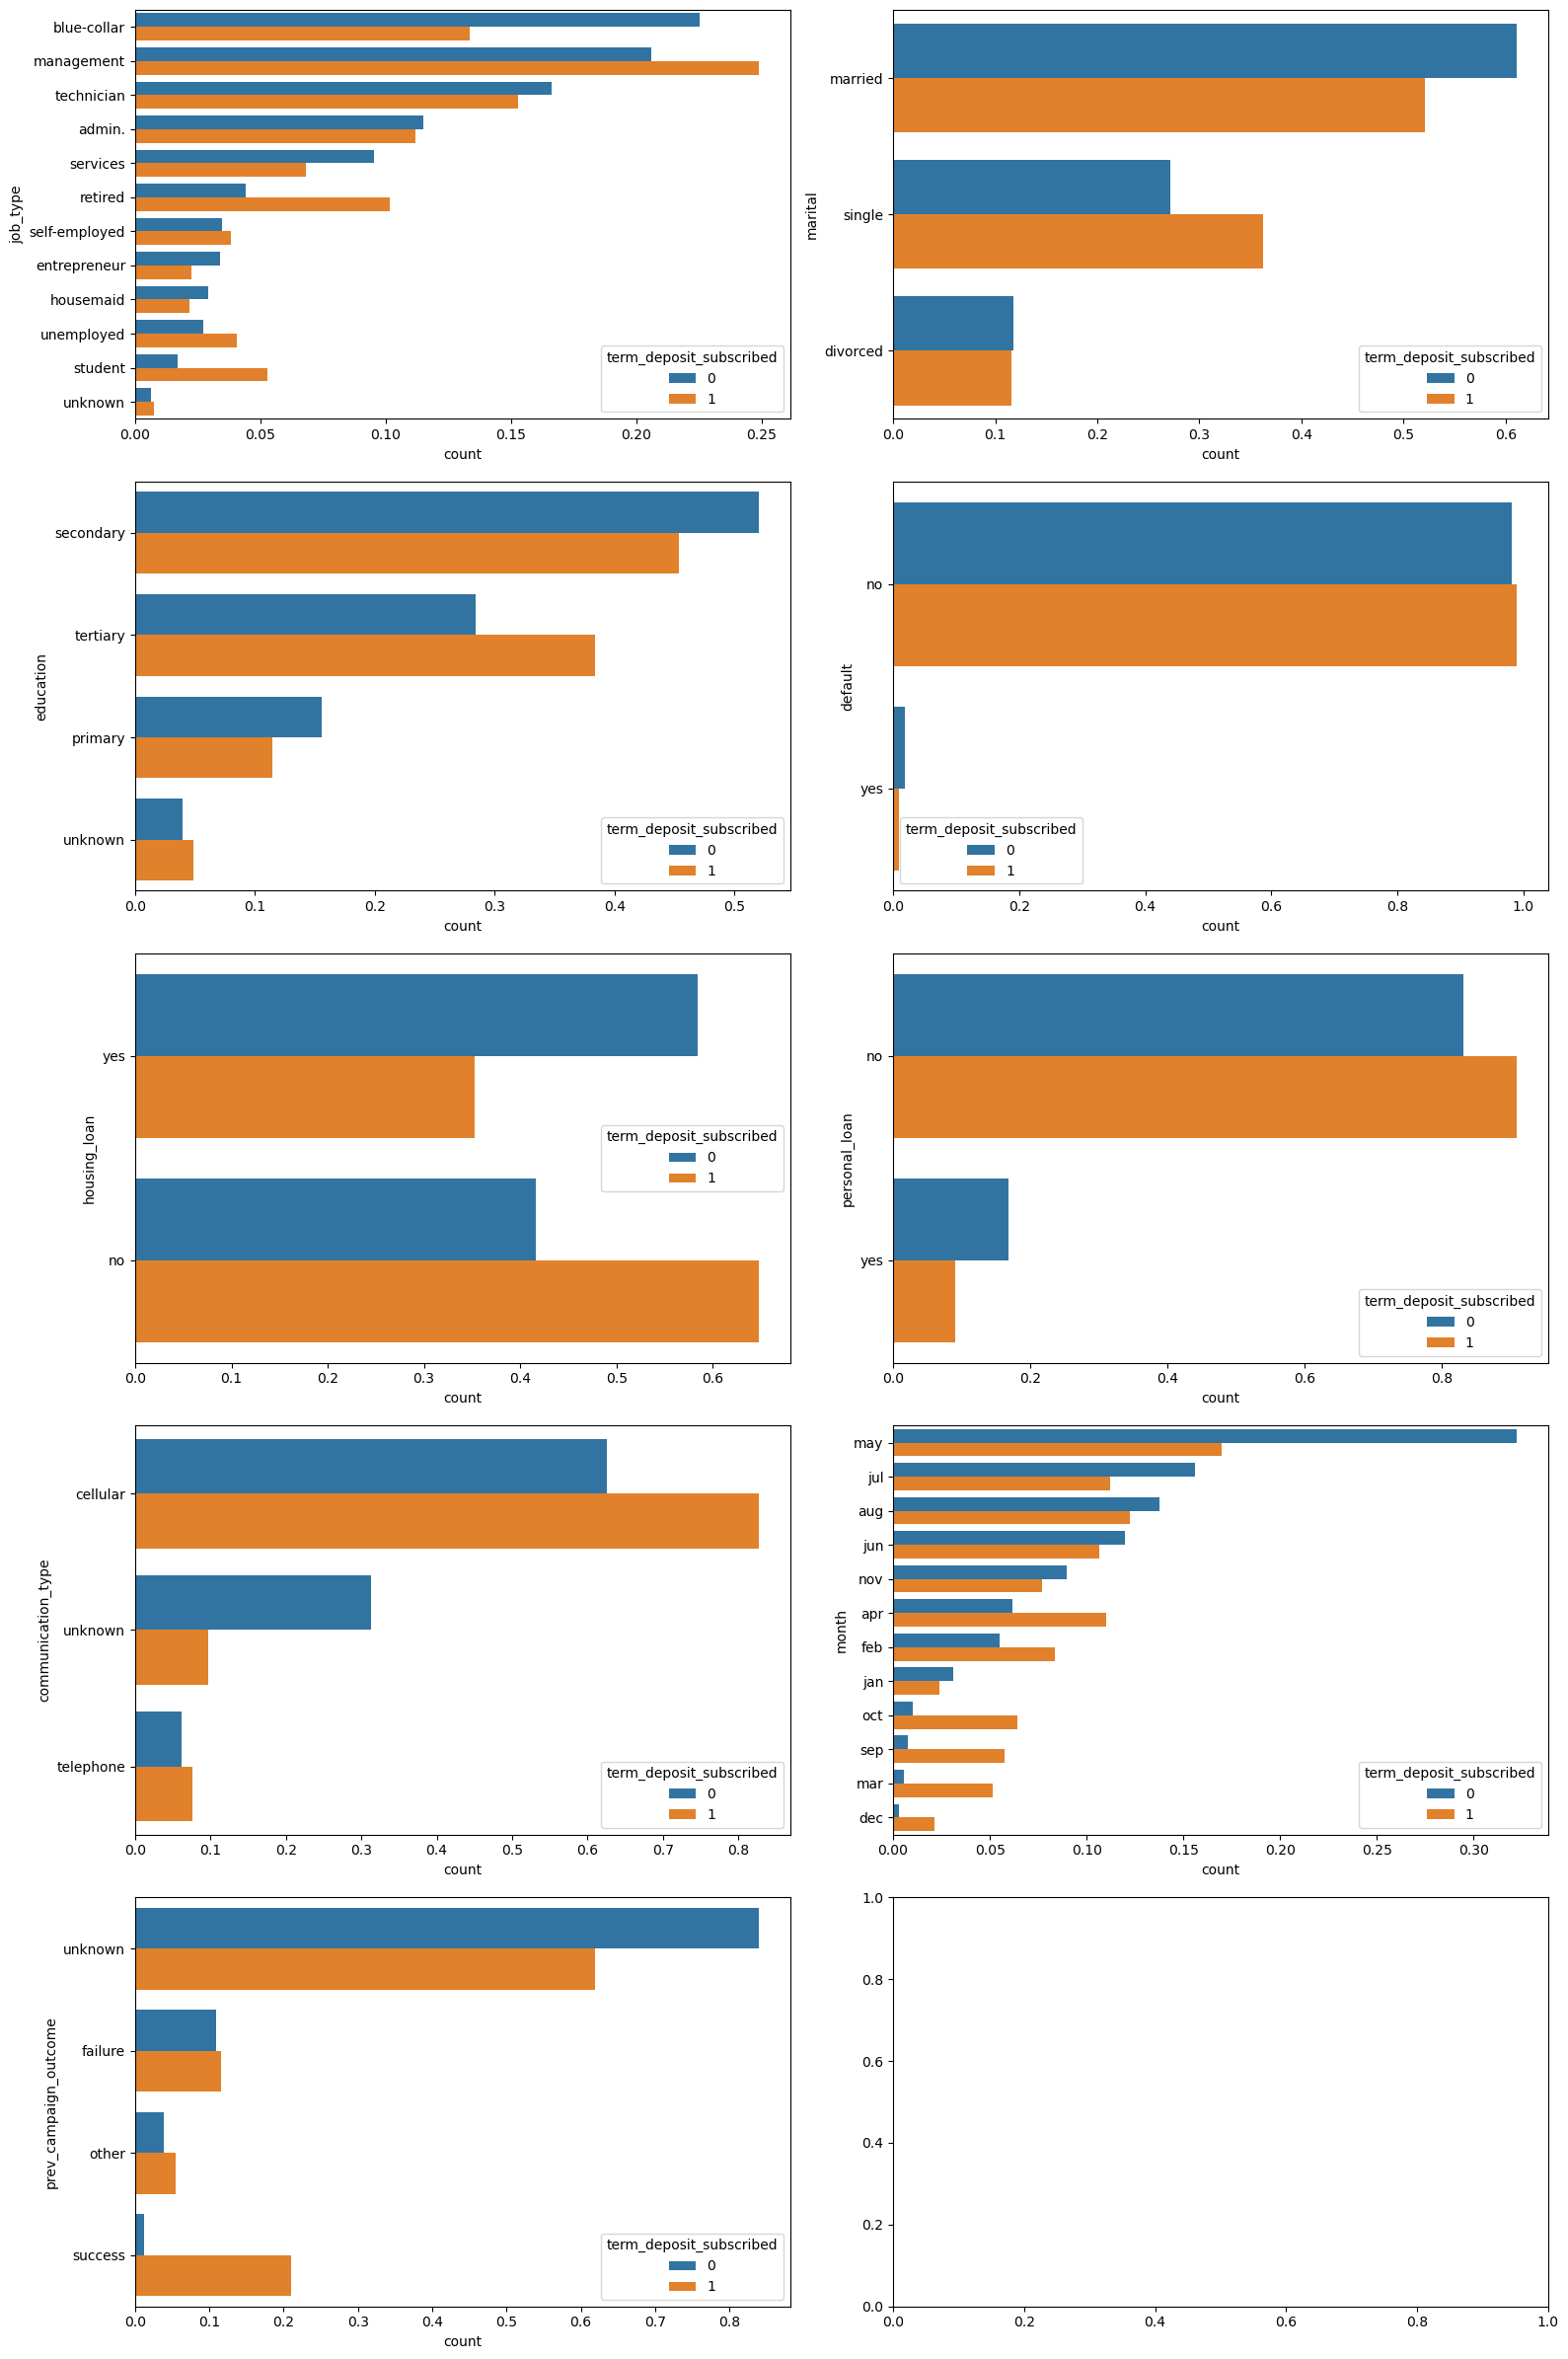

In [9]:
fig, axes = plt.subplots(5, 2, figsize=(16, 24))
axes = axes.flatten()

target_col = 'term_deposit_subscribed'

for ax, col in zip(axes, cat_col):

    vc_0 = df[df[target_col] == 0][col].value_counts(normalize=True).reset_index().rename(columns={'index': col, 'proportion': 'count'})
    vc_0[target_col] = 0

    vc_1 =df[df[target_col] == 1][col].value_counts(normalize=True).reset_index().rename(columns={'index': col, 'proportion': 'count'})
    vc_1[target_col] = 1

    result = pd.concat([vc_0, vc_1], ignore_index=True)

    sns.barplot(
        data=result,
        y=col,
        x='count',
        hue=target_col,
        ax=ax
    )

plt.tight_layout()

In [10]:
print(cat_col)

['job_type', 'marital', 'education', 'default', 'housing_loan', 'personal_loan', 'communication_type', 'month', 'prev_campaign_outcome']


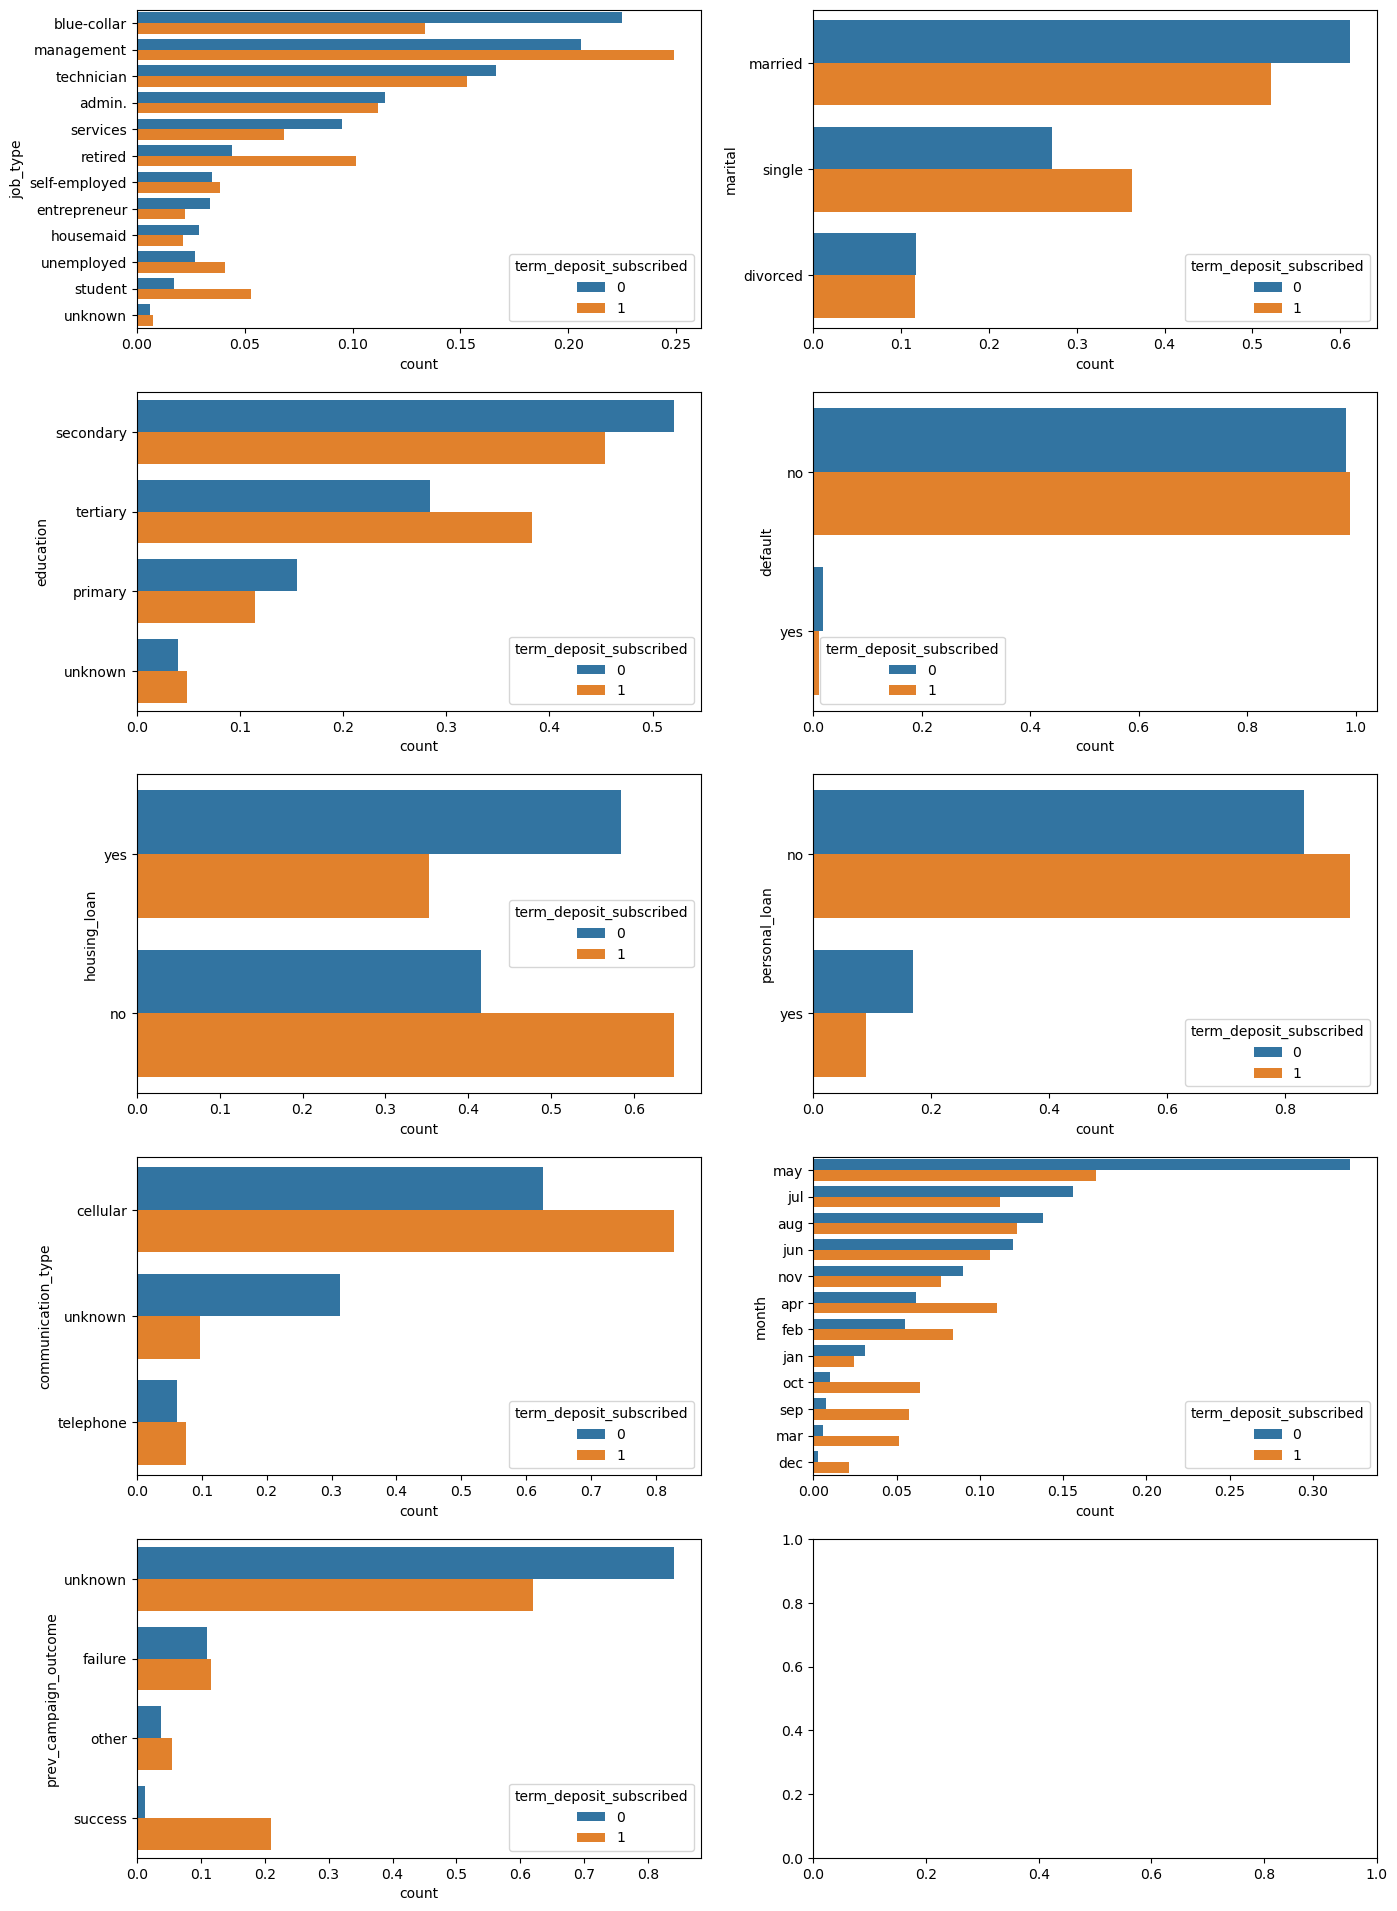

In [11]:
fig, axes = plt.subplots(5, 2, figsize=(16,24))

axes = [ax for axes_rows in axes for ax in axes_rows]

target_col = 'term_deposit_subscribed'

for i, column in enumerate(df[cat_col]):

    fltr = df[target_col]==0
    
    vc_a=df[fltr][column].value_counts(normalize=True).reset_index().rename({'index':column,'proportion':'count'},axis=1)
    vc_b=df[~fltr][column].value_counts(normalize=True).reset_index().rename({'index':column,'proportion':'count'},axis=1)
    
    #إضافة عمود جديد
    vc_a[target_col]=0
    vc_b[target_col]=1
    
    # print(vc_a)
    # print(vc_b)
    
    #دمج أطر البيانات في إطار بيانات واحد
    result = pd.DataFrame()
    result = pd.concat([result, vc_a, vc_b]).reset_index(drop=True)
    #الرسم
    sns.barplot(y=column, x='count', data=result, hue=target_col, ax=axes[i])

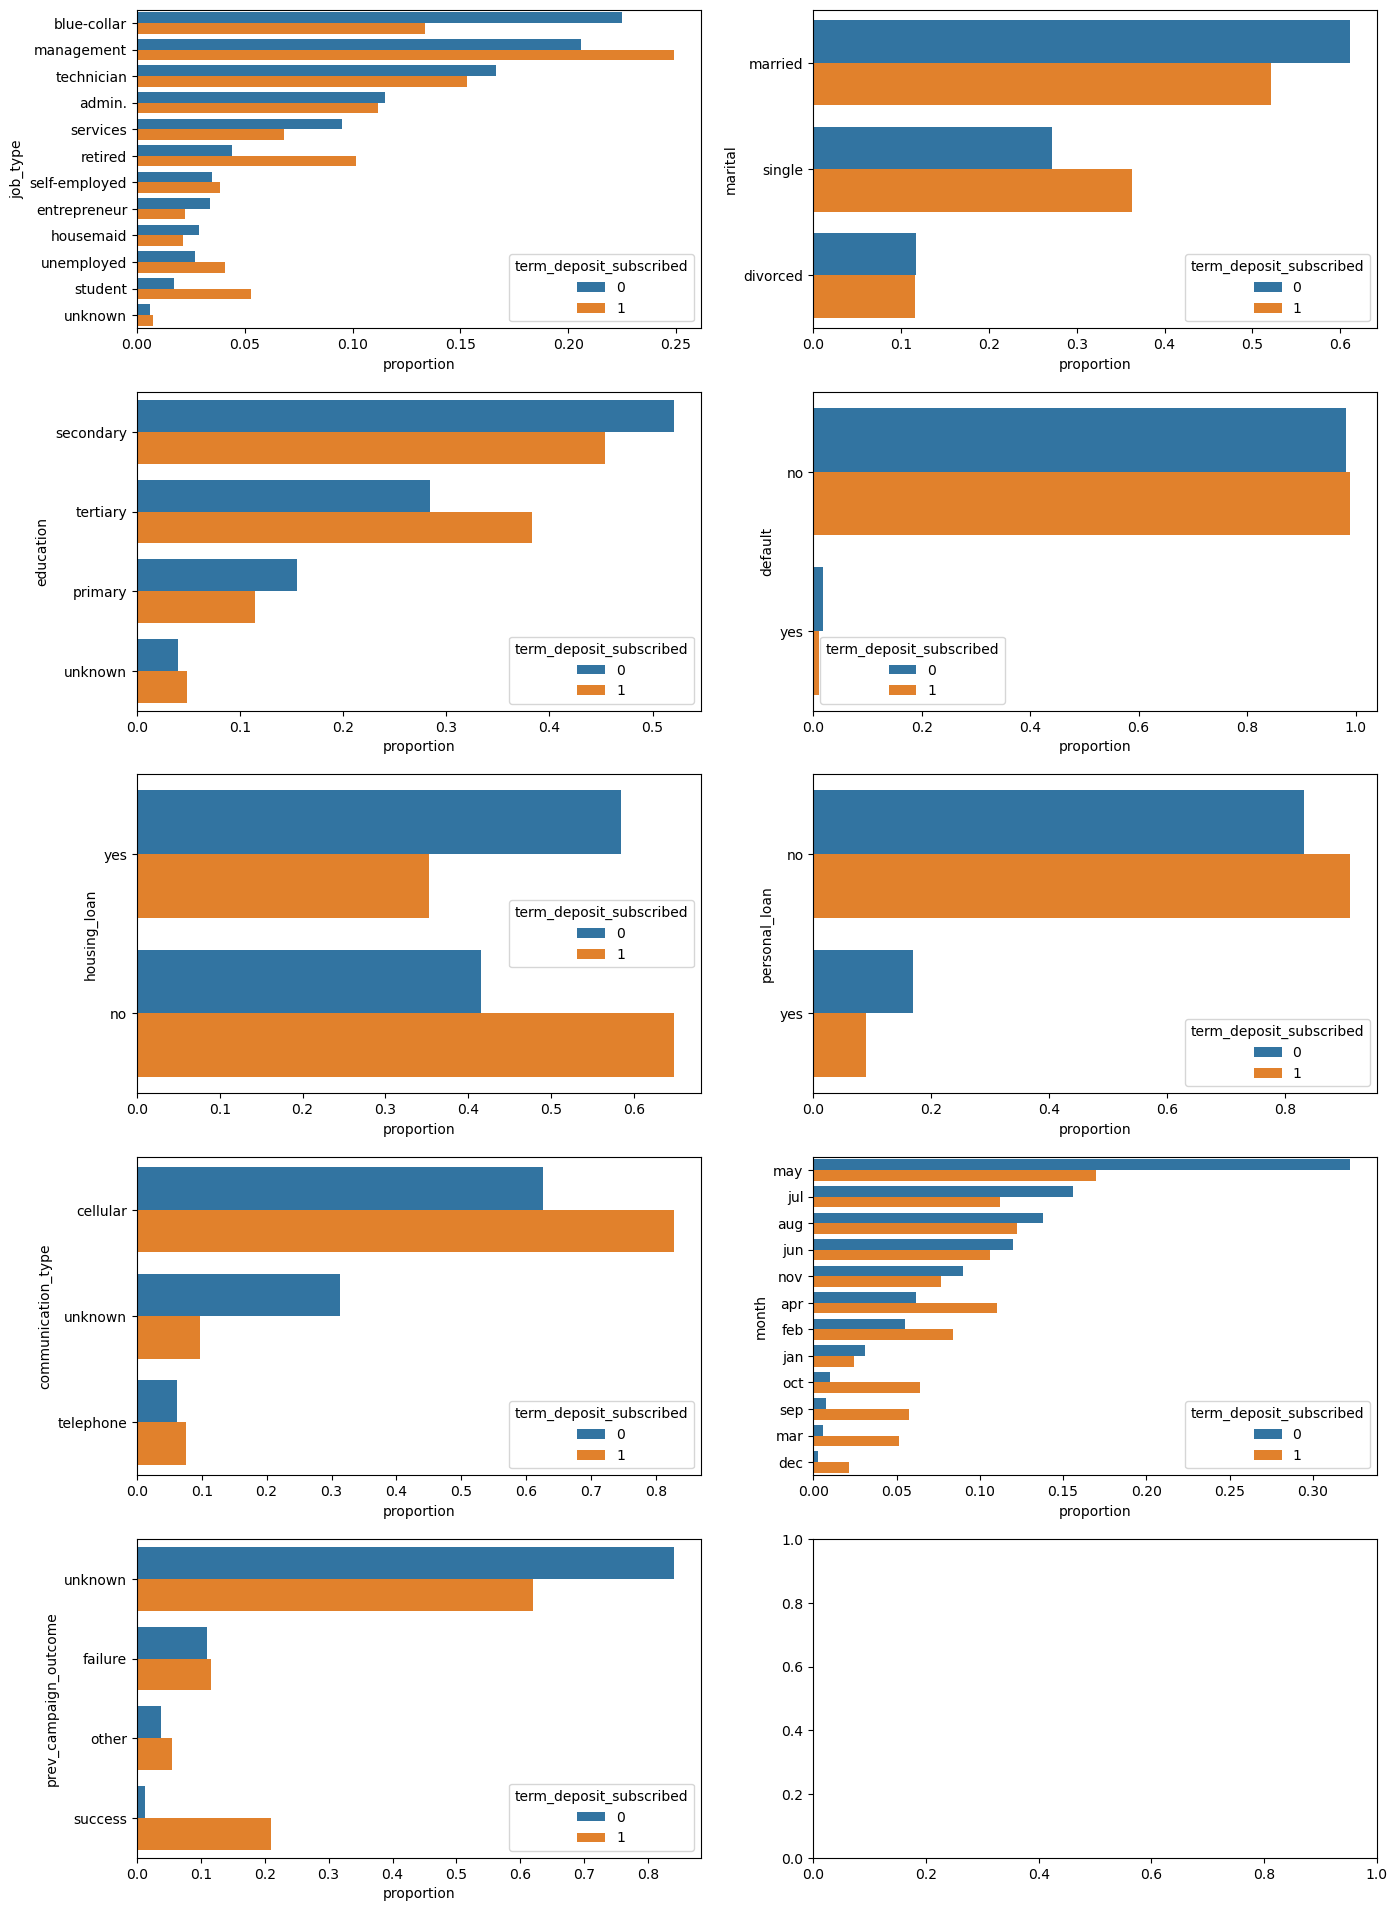

In [12]:
fig, axes = plt.subplots(5,2, figsize=(16,24))
axes = [ax for ax_row in axes for ax in ax_row]

target_col = 'term_deposit_subscribed'

for i, column in enumerate(df[cat_col]):
    fltr = df[target_col] == 0
    vc_a = df[fltr][column].value_counts(normalize=True).reset_index().rename({'index': column}, axis=1)
    vc_b = df[~fltr][column].value_counts(normalize=True).reset_index().rename({'index': column}, axis=1)

    # اضافه اعمده جديده 
    vc_a[target_col] = 0
    vc_b[target_col] = 1

    # print(vc_a)
    # print(vc_b)

    #  دمج اطار البيانات فى اطار بيانات واحد
    result = pd.DataFrame()
    result = pd.concat([result, vc_a, vc_b]).reset_index(drop=True)
    # print(result)

    # # رسم البيانات
    sns.barplot(y=column, x='proportion', data=result, hue=target_col, ax=axes[i] )

Index(['count', 'job_type', 'term_deposit_subscribed'], dtype='object')
Index(['count', 'marital', 'term_deposit_subscribed'], dtype='object')
Index(['count', 'education', 'term_deposit_subscribed'], dtype='object')
Index(['count', 'default', 'term_deposit_subscribed'], dtype='object')
Index(['count', 'housing_loan', 'term_deposit_subscribed'], dtype='object')
Index(['count', 'personal_loan', 'term_deposit_subscribed'], dtype='object')
Index(['count', 'communication_type', 'term_deposit_subscribed'], dtype='object')
Index(['count', 'month', 'term_deposit_subscribed'], dtype='object')
Index(['count', 'prev_campaign_outcome', 'term_deposit_subscribed'], dtype='object')


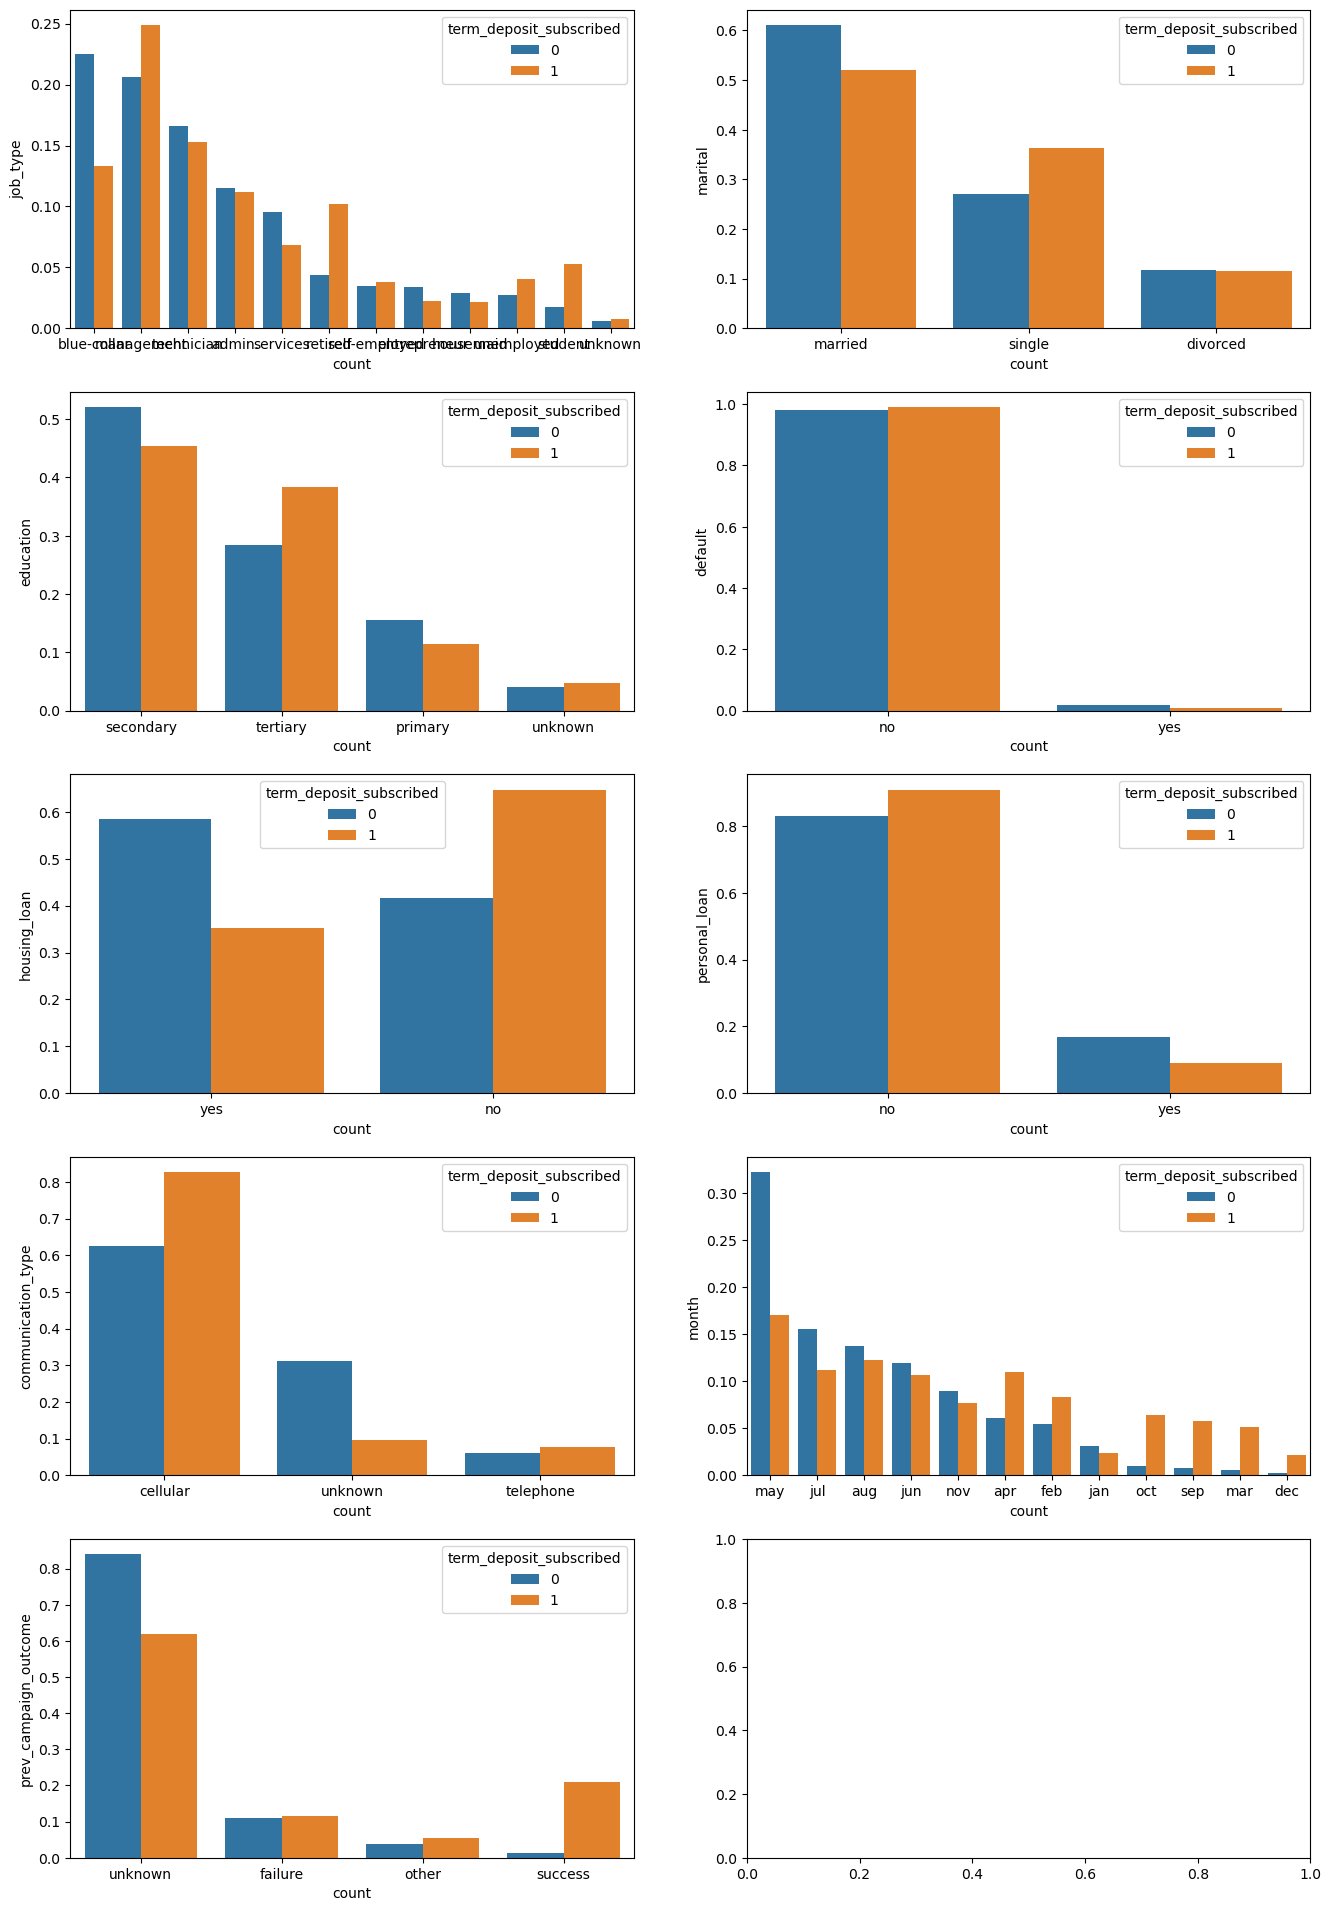

In [13]:
fig, axes = plt.subplots(5,2, figsize=(16,24))
axes = [ax for ax_row in axes for ax in ax_row]

target_col = 'term_deposit_subscribed'
for i, column in enumerate(df[cat_col]):
    fltr = df[target_col]==0
    
    vc_a = df[fltr][column].value_counts(normalize=True).reset_index().rename({'index':column,column:'count'}, axis=1)
    vc_b = df[~fltr][column].value_counts(normalize=True).reset_index().rename({'index':column,column:'count'}, axis=1)
    
    vc_a[target_col] = 0
    vc_b[target_col] = 1
   
    result = pd.concat([vc_a, vc_b]).reset_index(drop=True)
    result = result.rename(columns={'proportion': column})
    print(result.columns)
    
    sns.barplot(y=column , x='count', data=result, hue=target_col, ax=axes[i])
    

In [14]:
cat2_col = df.select_dtypes(exclude='object').columns.difference([id,'term_deposit_subscribed']).tolist()
cat2_col

['balance',
 'customer_age',
 'day_of_month',
 'days_since_prev_campaign_contact',
 'last_contact_duration',
 'num_contacts_in_campaign',
 'num_contacts_prev_campaign']

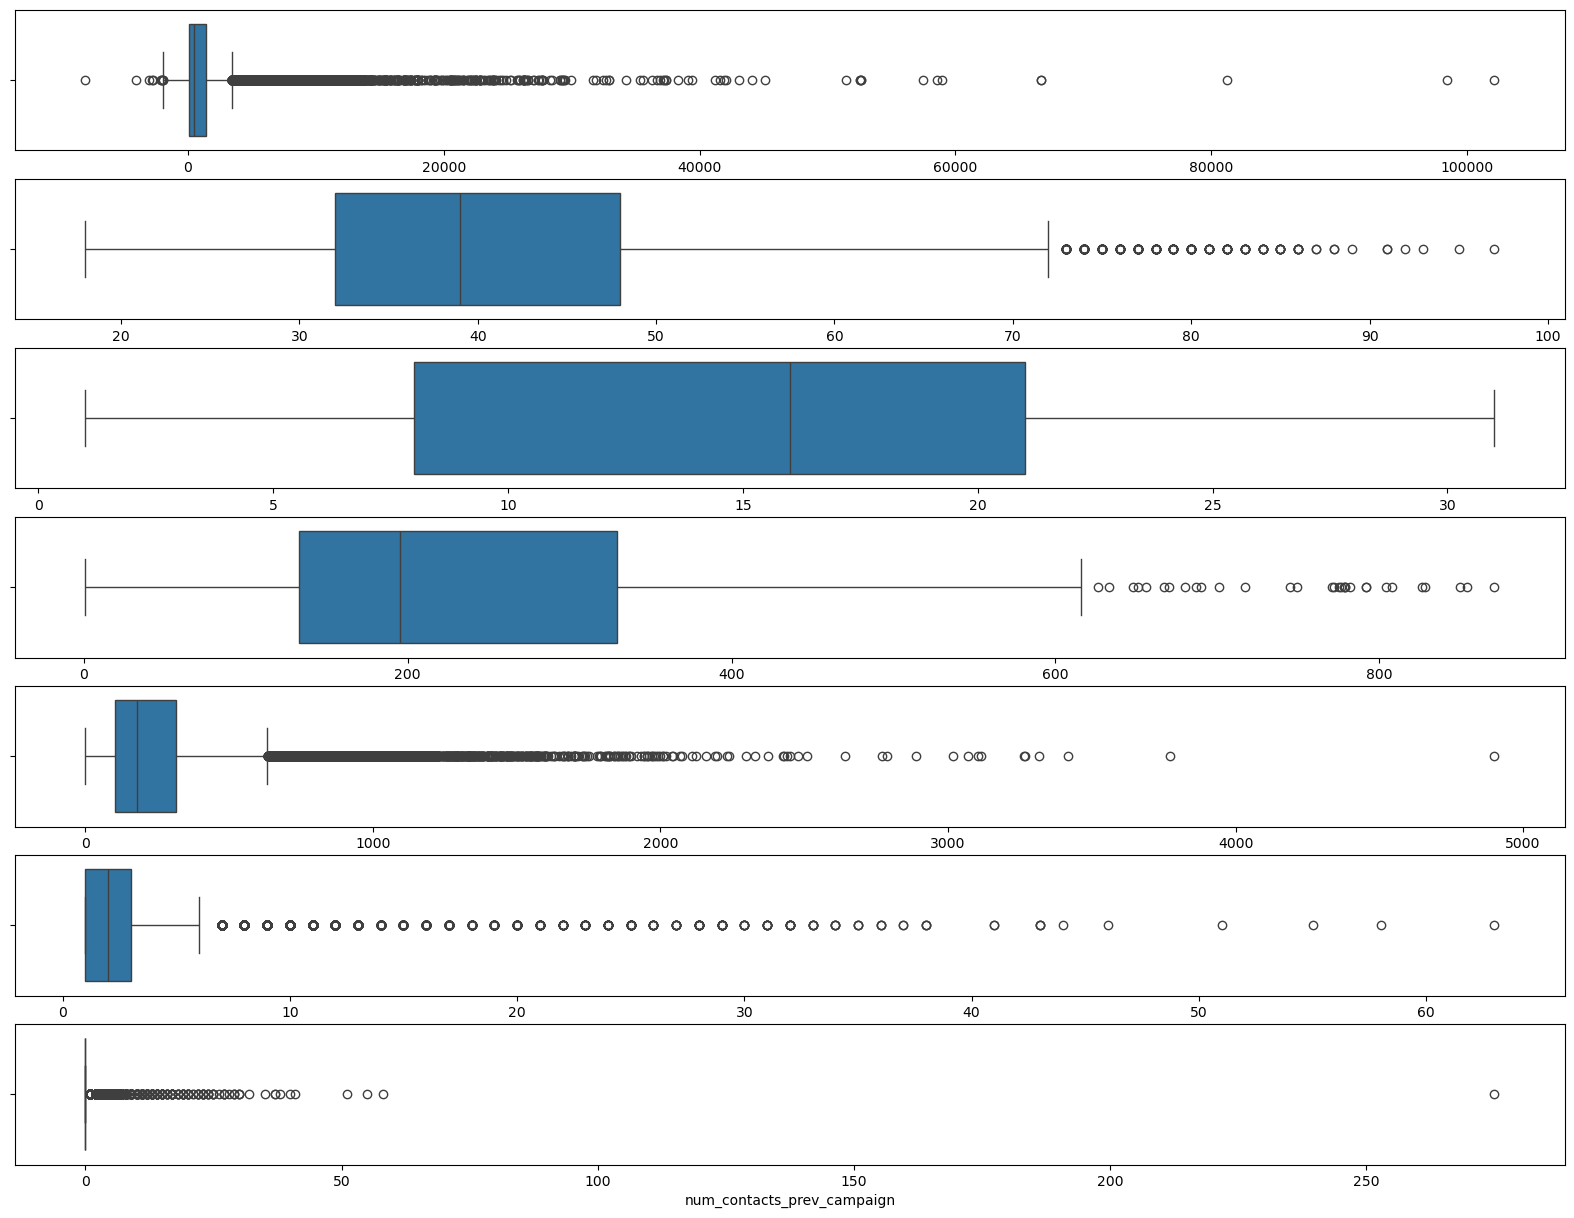

In [15]:
fig , axes = plt.subplots(7,1 , figsize=(20 ,15))
axes= axes.flatten()
for ax , col in zip(axes ,cat2_col):
    sns.boxplot(ax = ax , vert=False , x=col , data=df)

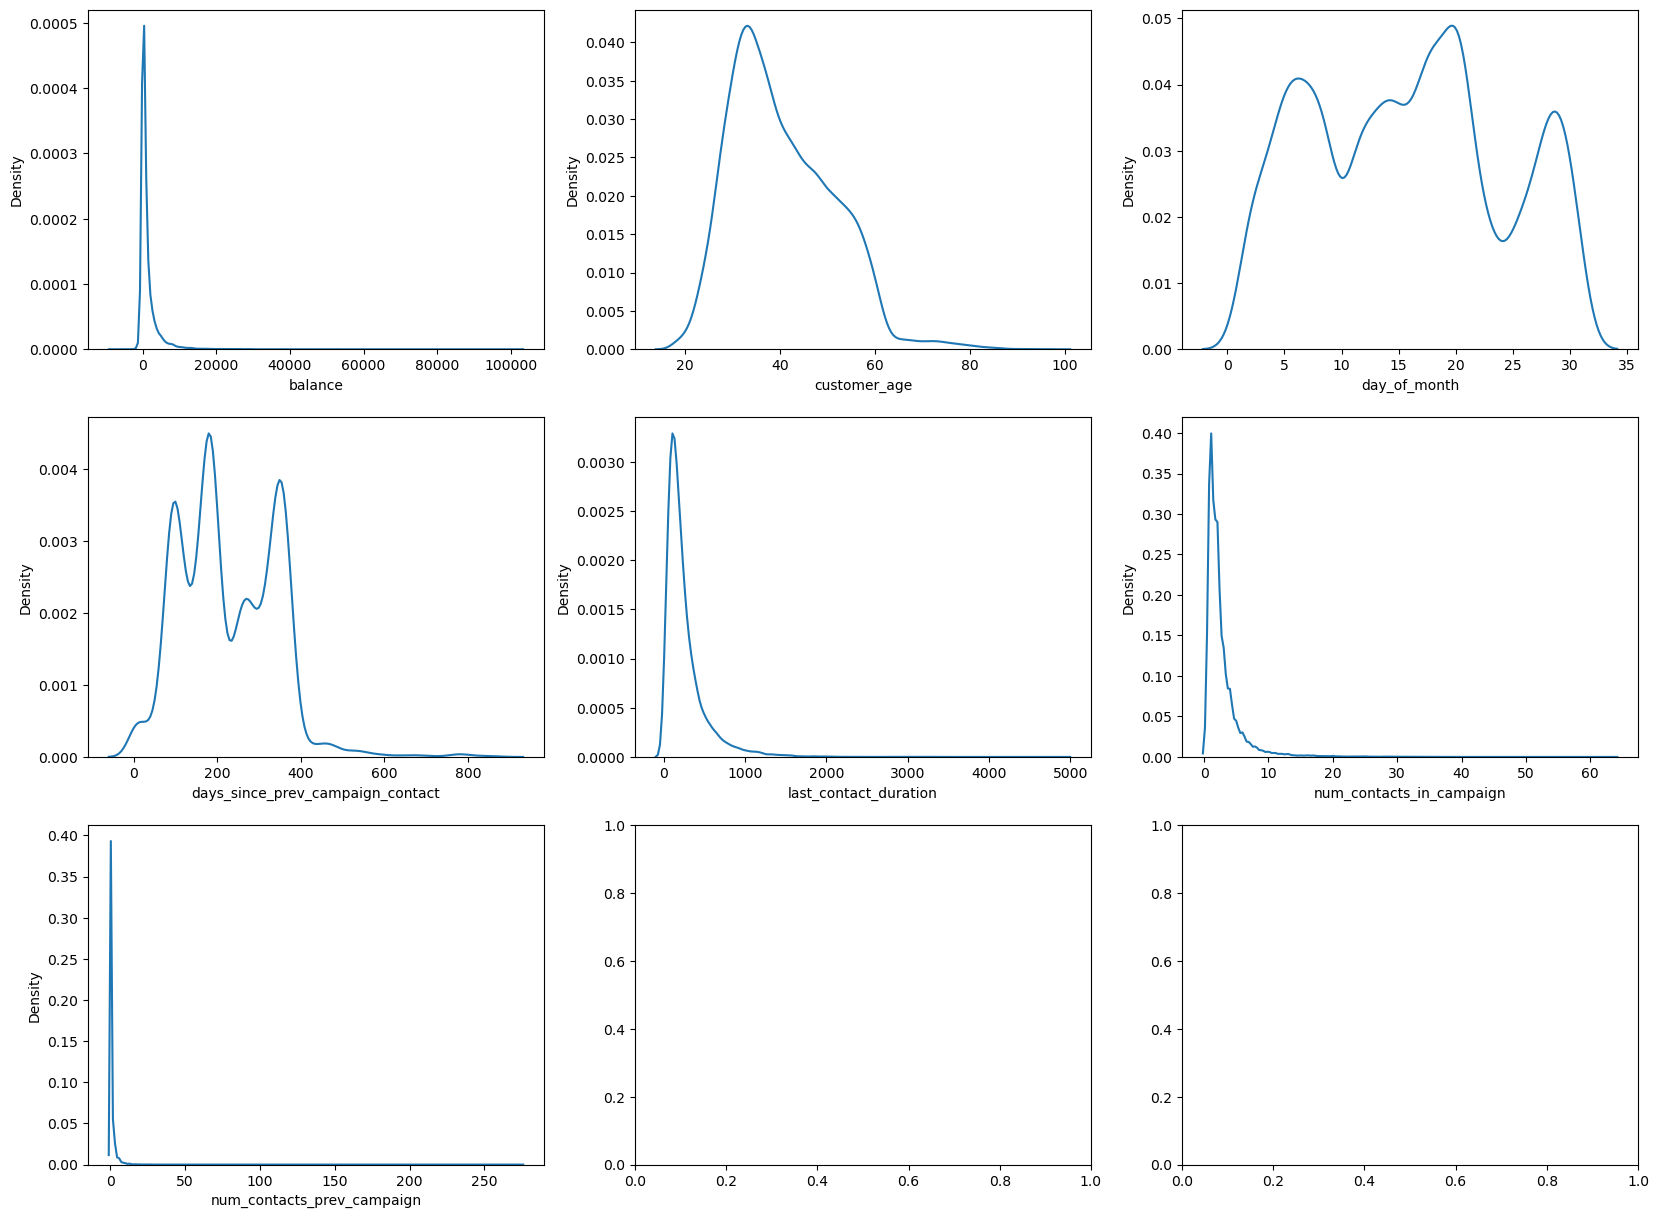

In [16]:
fig , axes = plt.subplots(3,3 , figsize=(20 ,15))
axes= axes.flatten()
for ax , col in zip(axes ,cat2_col):
    sns.kdeplot(ax = ax  , x=col , data=df)

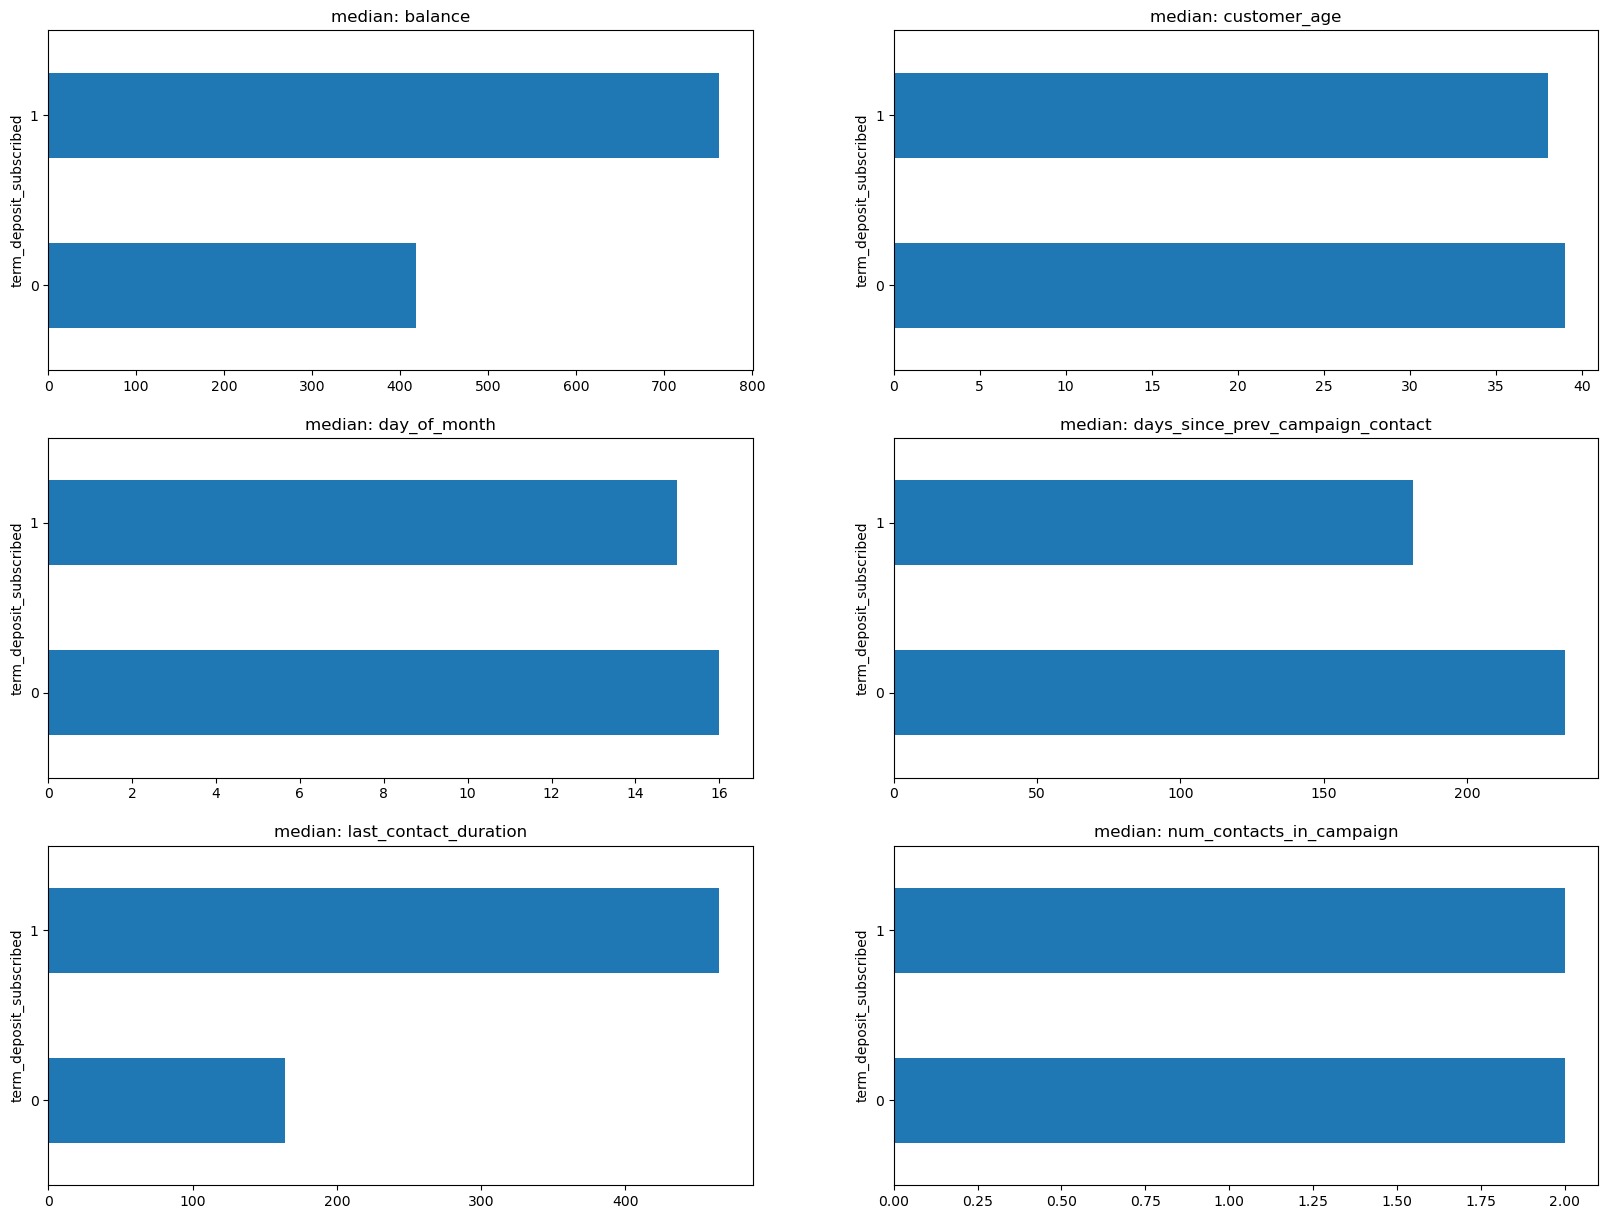

In [17]:
fig , axes = plt.subplots(3,2 , figsize=(20 ,15))
axes= axes.flatten()
for ax , col in zip(axes ,cat2_col):
    df.groupby(target_col)[col].median().plot.barh(ax = ax , title=f'median: {col}' )

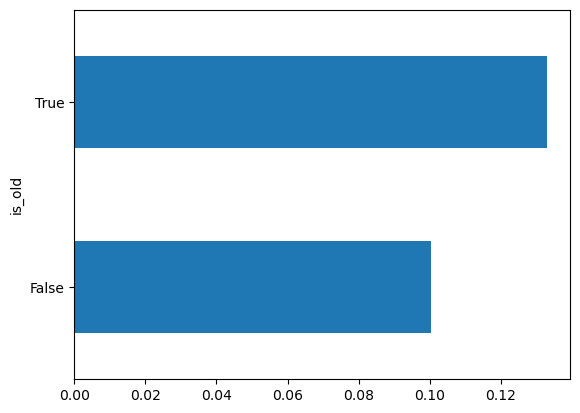

In [28]:
df['is_old'] = True
df.loc[df['customer_age'] <= 50 , 'is_old'] = False
_ =df.groupby('is_old')[target_col].mean().sort_values().plot.barh()

In [29]:
df

,id,customer_age,job_type,marital,education,default,balance,housing_loan,personal_loan,communication_type,day_of_month,month,last_contact_duration,num_contacts_in_campaign,days_since_prev_campaign_contact,num_contacts_prev_campaign,prev_campaign_outcome,term_deposit_subscribed,is_old
0,id_43823,28.0,management,single,tertiary,no,285.0,yes,no,unknown,26,jun,303.0,4.0,NaN,0,unknown,0,False
1,id_32289,34.0,blue-collar,married,secondary,no,934.0,no,yes,cellular,18,nov,143.0,2.0,132.0,1,other,0,False
2,id_10523,46.0,technician,married,secondary,no,656.0,no,no,cellular,5,feb,101.0,4.0,NaN,0,unknown,0,False
3,id_43951,34.0,services,single,secondary,no,2.0,yes,no,unknown,20,may,127.0,3.0,NaN,0,unknown,0,False
4,id_40992,41.0,blue-collar,married,primary,no,1352.0,yes,no,cellular,13,may,49.0,2.0,NaN,0,unknown,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31642,id_27290,58.0,admin.,married,secondary,no,567.0,yes,no,cellular,2,feb,99.0,2.0,265.0,3,other,0,True
31643,id_20428,51.0,management,married,tertiary,no,1072.0,no,no,unknown,20,jun,31.0,7.0,NaN,0,unknown,0,True
31644,id_44679,41.0,unemployed,married,primary,no,242.0,yes,no,unknown,23,may,89.0,2.0,NaN,0,unknown,0,False
31645,id_4841,48.0,services,married,secondary,no,2699.0,no,no,cellular,11,aug,216.0,6.0,NaN,0,unknown,0,False
